In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage

In [3]:
load_dotenv()

True

In [4]:
llm = init_chat_model(model="gemini-3.5-flash-lite", model_provider="google_genai")

In [5]:
class LLMstate(TypedDict):
    question : str
    answer : str

In [6]:
def llm_call(state : LLMstate):
    question = state['question']
    state['answer'] = llm.invoke([HumanMessage(content=question)]).content
    return state

In [7]:
graph = StateGraph(LLMstate)

graph.add_node('llm_call', llm_call)

graph.add_edge(START, 'llm_call')
graph.add_edge('llm_call', END)

workflow = graph.compile()

In [ ]:
initial_state = {'question': 'Hi'}
final_state = workflow.invoke(initial_state)
print(final_state)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'question': 'Hi', 'answer': [{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'El4KXAERTTIPY5QySCJr+B5QQ98F2LfrBlon/MKpA19CEA3o3BCIhggROJLeEPChFf1pJLC8K1e3JDbaHSIkgGhJr470pSc2juO1Xu0BwPLYa2V9BUdLgQN1zcxdfDpt'}}]}


In [16]:
print(final_state['answer'][0]['text'])

Hello! How can I help you today?


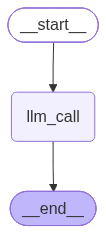

In [10]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))